In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
from tqdm import tqdm

import h5py

from joblib import Parallel, delayed

import pickle

import schwingerModel as sim

from schwingerModel.interpolator import MesonOp, mesonMultiplet, makeState

def triplet(op):                      
    return mesonMultiplet(op, 1)[+1]

def singlet(op):                       
    return mesonMultiplet(op, 0)[0]

In [2]:
# with open('configs/beta_3_m0_0.2_Nx_10_Nt_32.pkl', 'rb') as f:
#     modelObj = pickle.load(f)

# with open('configs/beta_3_m0_0.2_Nx_10_Nt_32_melted.pkl', 'rb') as f:
#     modelObjMelt = pickle.load(f)

with open('configs/50kSteps.pkl', 'rb') as f:
    modelObj = pickle.load(f)

with open('configs/50kSteps_melted.pkl', 'rb') as f:
    modelObjMelt = pickle.load(f)

In [3]:
Qs = sim.topology.getAllTopoQs(modelObj)
QsMelt = sim.topology.getAllTopoQs(modelObjMelt)

In [4]:
np.mean(modelObjMelt.tunnelAcceptance)

np.float64(0.6474)

Text(0, 0.5, 'Density')

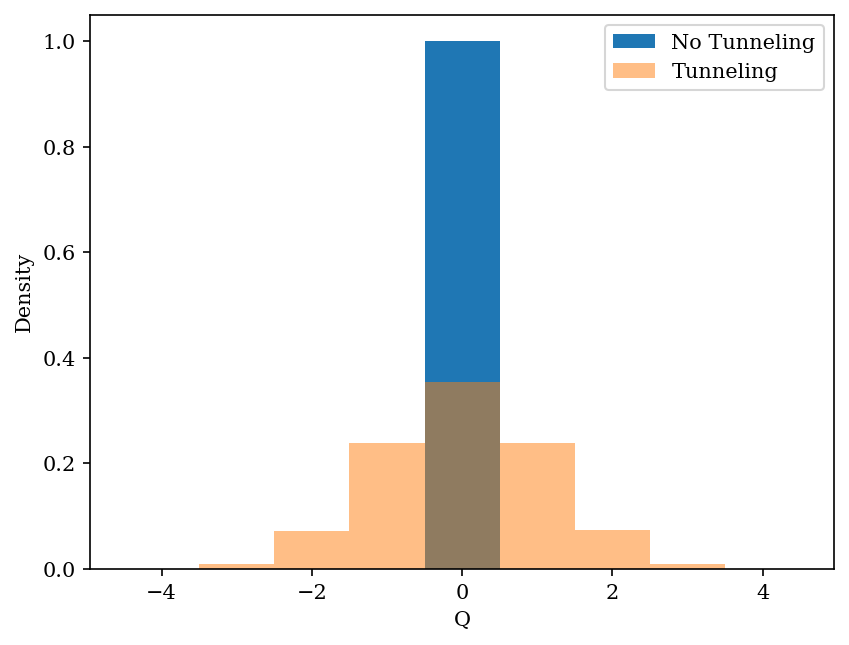

In [5]:
plt.figure(dpi=150)
plt.hist(Qs,density=True,bins=np.arange(-4.5,5.5),label="No Tunneling")
plt.hist(QsMelt,density=True,bins=np.arange(-4.5,5.5),alpha=.5,label="Tunneling")
plt.legend()
plt.xlabel("Q")
plt.ylabel("Density")

In [6]:
# with open('configs/beta_3_m0_0.2_Nx_10_Nt_32_melted.pkl', 'rb') as f:
#     modelObjMelt = pickle.load(f)

# sim.distillation.generateDistillFile(modelObj=modelObjMelt,filePath="./configs/beta_3_m0_0.2_Nx_10_Nt_32_melted.hdf5",numVecs=5,autocorrSkip=50,DNums=(0,1,2),momks=(0,1,2))

In [7]:
path = './configs/beta_4_m0_0.0_Nx_16_Nt_32_melted.hdf5'

In [8]:
meta = sim.distillation.readDistillMeta(path)

In [9]:
pionBasis = [triplet(MesonOp("g5")),triplet(MesonOp("g5",DNum=2))]
etaBasis = [singlet(MesonOp("g5")),singlet(MesonOp("g5",DNum=2))]

In [10]:
pionCorrels = sim.GEVP.measureEnsemble(path,(meta.configIndices),pionBasis)
etaCorrels = sim.GEVP.measureEnsemble(path,(meta.configIndices),etaBasis)

Measuring configs: 100%|██████████| 1000/1000 [00:01<00:00, 750.41it/s]


In [11]:
gevpTi = 1
pionPrinCorrels = sim.GEVP.bootstrapEnsemble(pionCorrels, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi,shift=1))
etaPrinCorrels = sim.GEVP.bootstrapEnsemble(etaCorrels, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi,shift=1))

In [12]:
pionMass = sim.GEVP.bootstrapEnsemble(pionCorrels,reduce=sim.GEVP.massReduce(ti=gevpTi, shift=1,
                                  fitT=[2,6], withAmp=True))
etaMass = sim.GEVP.bootstrapEnsemble(etaCorrels,reduce=sim.GEVP.massReduce(ti=gevpTi, shift=1,
                                  fitT=[2,6], withAmp=True))

(1e-06, 2.0)

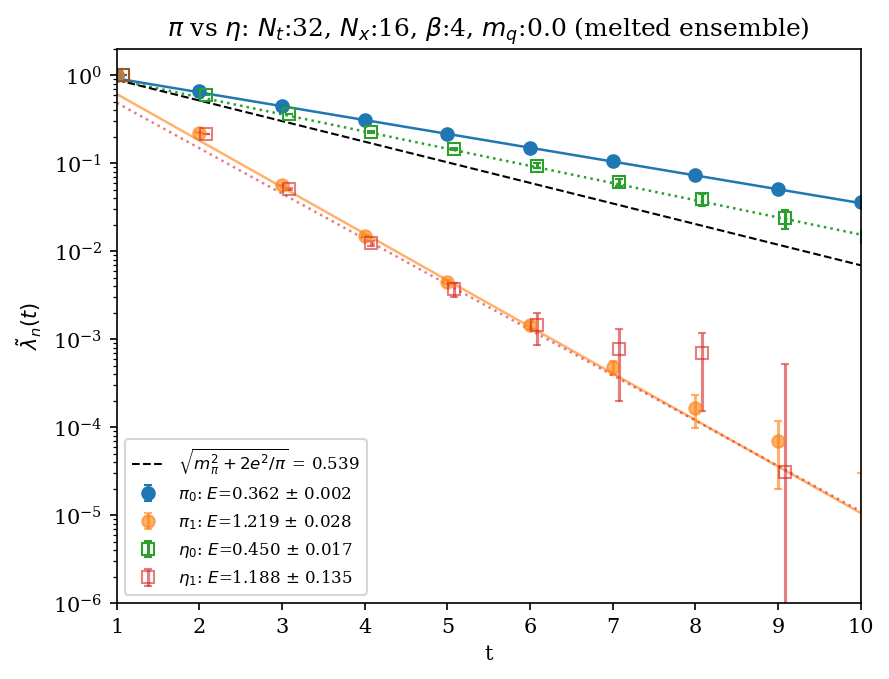

In [13]:
# principal correlators + fitted masses, pi vs eta, on the melted ensemble
piE,  logApi  = pionMass[0][:, 0], pionMass[0][:, 1]
piErr  = pionMass[1][:, :, 0].mean(axis=0)     # symmetrized mass errors per state
etaE, logAeta = etaMass[0][:, 0], etaMass[0][:, 1]
etaErr = etaMass[1][:, :, 0].mean(axis=0)

# anomaly prediction: the singlet picks up the Schwinger mass in quadrature,
#   m_eta^2 = m_pi^2 + 2 e^2/pi,   e^2 = 1/(a^2 beta)
mS2 = 2/(np.pi * meta.beta * meta.a**2)
etaPred = np.sqrt(piE[0]**2 + mS2)

tf = np.linspace(gevpTi, 12, 300)

plt.figure(dpi=150)
# pi: filled circles, solid fits.  eta: open squares, dotted fits, slight t-offset
# (pi_1 and eta_1 are nearly degenerate, so without this they plot on top of each other)
for name, out, E, Err, logA, fmt, mfc, lstyle, dt in [
        (r"$\pi$",  pionPrinCorrels, piE,  piErr,  logApi,  'o', None,   '-', 0.0),
        (r"$\eta$", etaPrinCorrels,  etaE, etaErr, logAeta, 's', 'none', ':', 0.08)]:
    central, err, cov = out
    ts = np.arange(gevpTi, gevpTi + central.shape[0])   # times of the shifted curves
    for e in range(central.shape[1]):
        fade = 1.0 if e == 0 else 0.6                   # ground state solid, excited faded
        line = plt.errorbar(ts + dt, central[:, e], yerr=np.maximum(err[::-1, :, e], 0),
                            fmt=fmt, markerfacecolor=mfc, capsize=2, ls='none', alpha=fade,
                            label=rf"{name}$_{e}$: $E$={E[e]:.3f} $\pm$ {Err[e]:.3f}")
        # fitted exponential from massReduce: exp(logA - E*(t - gevpTi))
        plt.plot(tf, np.exp(logA[e] - E[e]*(tf - gevpTi)), lstyle,
                 color=line[0].get_color(), lw=1.2, alpha=fade)

# slope the eta ground state SHOULD have if only the anomaly separated it from the pi
plt.plot(tf, np.exp(logAeta[0] - etaPred*(tf - gevpTi)), 'k--', lw=1,
         label=rf"$\sqrt{{m_\pi^2+2e^2/\pi}}$ = {etaPred:.3f}")

plt.semilogy()
plt.xlabel("t"); plt.ylabel(r"$\tilde\lambda_n(t)$")
plt.legend(fontsize=8)
plt.title(rf"$\pi$ vs $\eta$: $N_t$:{meta.dimt}, $N_x$:{meta.dimx}, "
          rf"$\beta$:{meta.beta}, $m_q$:{meta.fMass} (melted ensemble)")
plt.xlim([1, 10])
plt.ylim([1e-6, 2e0])

# Theta Spectroscopy

In [14]:
with h5py.File(path, 'r') as f:
    Qs = np.array([sim.topology.getTopoQ(f[f"cfg{i:05d}"]['links'][:])
                   for i in meta.configIndices])

In [21]:
thetas = np.linspace(0,3/4*np.pi,16)
weights = np.exp(1j*thetas[:,np.newaxis]*Qs)


gevpTi = 1

validity = np.abs(np.mean(weights,axis=1))

pionMassTheta = Parallel(n_jobs=-1)(delayed(sim.GEVP.bootstrapEnsemble)(pionCorrels, weights=weights[i],
                                              reduce=sim.GEVP.massReduce(ti=gevpTi, shift=1,
                                              fitT=[2,7], withAmp=True)) for i in range(len(weights)))

etaMassTheta = Parallel(n_jobs=-1)(delayed(sim.GEVP.bootstrapEnsemble)(etaCorrels, weights=weights[i],
                                              reduce=sim.GEVP.massReduce(ti=gevpTi, shift=1,
                                              fitT=[2,5], withAmp=True)) for i in range(len(weights)))

/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:204: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 7% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "
/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:204: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 0% (components failing >5%: 0)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "
/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:204: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 43% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "
/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:204: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fract

Text(0.5, 0, '$\\pi$')

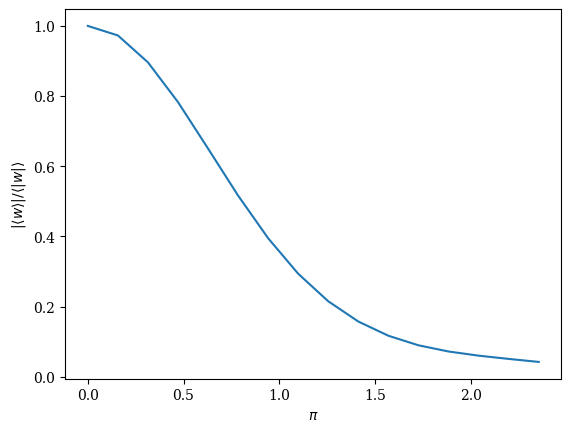

In [22]:
plt.plot(thetas,validity)
plt.ylabel(r"$|\langle w \rangle|/\langle |w| \rangle$")
plt.xlabel(r"$\pi$")

In [23]:
etaMasses = [etaMassTheta[i][0][0,0] for i in range(len(thetas))]
pionMasses = [pionMassTheta[i][0][0,0] for i in range(len(thetas))]

etaMassesErr = [np.mean(etaMassTheta[i][1][0,0]) for i in range(len(thetas))]
pionMassesErr = [np.mean(pionMassTheta[i][1][0,0]) for i in range(len(thetas))]

Text(0.5, 1.0, '$\\pi$ vs $\\eta$: $N_t$:32, $N_x$:16, $\\beta$:4, $m_q$:0.0 (melted ensemble)')

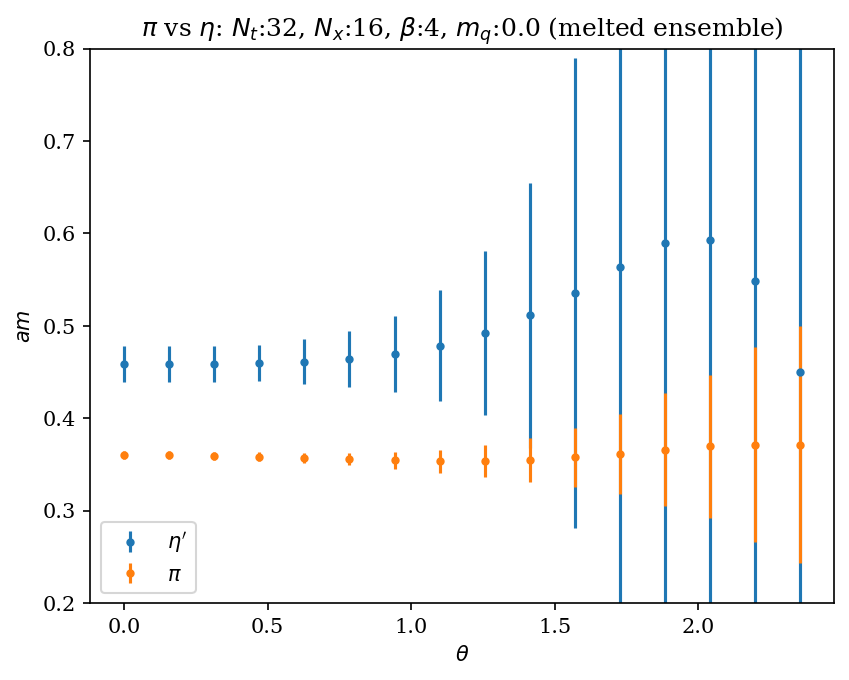

In [30]:
plt.figure(dpi=150)
plt.errorbar(x=thetas,y=etaMasses, yerr=etaMassesErr, label=r"$\eta'$",fmt=".")
plt.errorbar(x=thetas,y=pionMasses, yerr = pionMassesErr, label=r"$\pi$",fmt=".")
plt.legend(loc="lower left")
plt.ylim([.2,.8])
plt.ylabel("$am$")
plt.xlabel(r"$\theta$")
plt.title(rf"$\pi$ vs $\eta$: $N_t$:{meta.dimt}, $N_x$:{meta.dimx}, "
          rf"$\beta$:{meta.beta}, $m_q$:{meta.fMass} (melted ensemble)")

In [25]:
np.std(Qs)

np.float64(1.4943142239836975)

(0.0, 0.3)

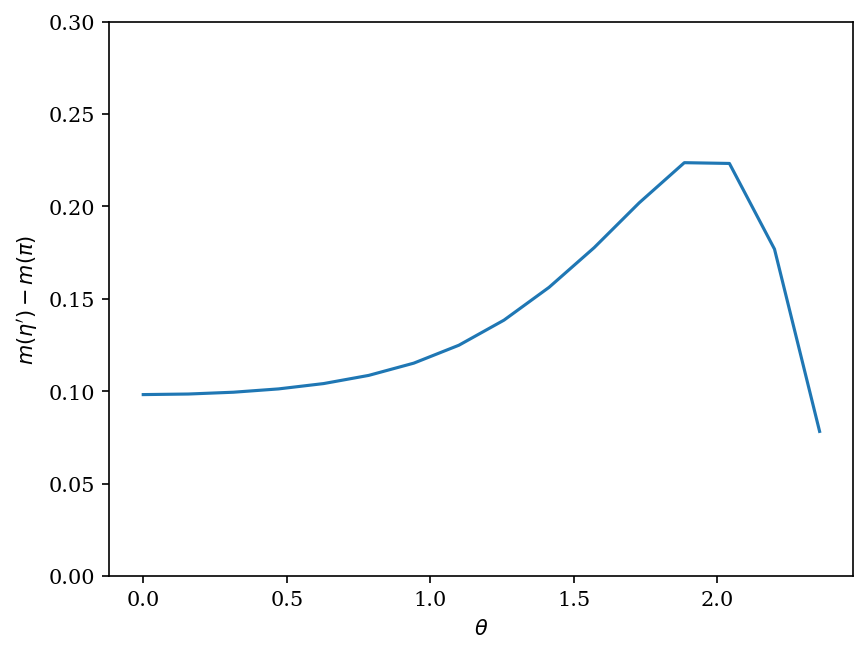

In [27]:
plt.figure(dpi=150)
plt.plot(thetas, np.array(etaMasses)-np.array(pionMasses))
plt.xlabel(r"$\theta$")
plt.ylabel(r"$m(\eta')-m(\pi)$")
plt.ylim([0,.3])